In [1]:
import pandas as pd
df = pd.read_csv('dataset.csv')
df.head()


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [4]:
df.isna().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [12]:
artist_mode=df['artists'].mode()[0]
track_name_mode=df['track_name'].mode()[0]

df.loc[df['artists'].isnull(), 'artists']=artist_mode
df.loc[df['track_name'].isnull(), 'track_name']=track_name_mode


In [17]:
print("\n===== 전처리 후 결측치 =====")
print(df[["artists", "track_name", "tempo", "popularity"]].isnull().sum())


===== 전처리 후 결측치 =====
artists       0
track_name    0
tempo         0
popularity    0
dtype: int64


In [19]:
print(df[["tempo", "popularity"]].info())
print(df[["tempo", "popularity"]].isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   tempo       114000 non-null  float64
 1   popularity  114000 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 MB
None
tempo         0
popularity    0
dtype: int64


In [22]:
print("tempo:", df["tempo"].min(), "~", df["tempo"].max())
print("popularity:", df["popularity"].min(), "~", df["popularity"].max())

tempo: 0.0 ~ 243.372
popularity: 0 ~ 100


In [23]:
df.loc[(df["popularity"] < 0) | (df["popularity"] > 100)]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


In [24]:
df[["tempo", "popularity"]].describe()


,tempo,popularity
count,114000.000000,114000.000000
mean,122.147837,33.238535
std,29.978197,22.305078
min,0.000000,0.000000
25%,99.218750,17.000000
50%,122.017000,35.000000
75%,140.071000,50.000000
max,243.372000,100.000000


In [25]:
df.isnull().sum()


Unnamed: 0          0
track_id            0
artists             0
album_name          1
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [26]:
album_name_mode_value=df['album_name'].mode()[0]
df['album_name'] = df['album_name'].fillna(album_name_mode_value)


In [27]:
df.isna().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [30]:
duplicate_count = df.duplicated().sum()
print("중복행의 갯수", duplicate_count)

중복행의 갯수 0


In [32]:
df = df.drop_duplicates().reset_index(drop=True)
print("중복 제거 후 데이터 개수:", len(df))


중복 제거 후 데이터 개수: 114000


In [33]:
print("\n[duration_ms 정제 전 요약 통계]")
print(df["duration_ms"].describe())

print("최솟값:", df["duration_ms"].min())
print("최댓값:", df["duration_ms"].max())


[duration_ms 정제 전 요약 통계]
count    1.140000e+05
mean     2.280292e+05
std      1.072977e+05
min      0.000000e+00
25%      1.740660e+05
50%      2.129060e+05
75%      2.615060e+05
max      5.237295e+06
Name: duration_ms, dtype: float64
최솟값: 0
최댓값: 5237295


In [39]:
df[(df['duration_ms']> 0) & (df['duration_ms']<= 1000000)].reset_index(drop=True)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113879,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113880,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113881,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113882,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [40]:
print("\n[정제 완료 후 전체 데이터 요약 통계]")
print(df.describe())


[정제 완료 후 전체 데이터 요약 통계]
          Unnamed: 0     popularity   duration_ms   danceability  \
count  114000.000000  114000.000000  1.140000e+05  114000.000000   
mean    56999.500000      33.238535  2.280292e+05       0.566800   
std     32909.109681      22.305078  1.072977e+05       0.173542   
min         0.000000       0.000000  0.000000e+00       0.000000   
25%     28499.750000      17.000000  1.740660e+05       0.456000   
50%     56999.500000      35.000000  2.129060e+05       0.580000   
75%     85499.250000      50.000000  2.615060e+05       0.695000   
max    113999.000000     100.000000  5.237295e+06       0.985000   

              energy            key       loudness           mode  \
count  114000.000000  114000.000000  114000.000000  114000.000000   
mean        0.641383       5.309140      -8.258960       0.637553   
std         0.251529       3.559987       5.029337       0.480709   
min         0.000000       0.000000     -49.531000       0.000000   
25%         0.4720

In [ ]:
# 1. 중복 행 개수 확인
duplicate_count = df.duplicated().sum()
print("중복 행 개수:", duplicate_count)


# 2. 중복 행 제거 + 인덱스 재정렬
df = df.drop_duplicates().reset_index(drop=True)

print("중복 제거 후 데이터 개수:", len(df))


# 3. duration_ms 요약 통계 확인
print("\n[duration_ms 정제 전 요약 통계]")
print(df["duration_ms"].describe())

print("최솟값:", df["duration_ms"].min())
print("최댓값:", df["duration_ms"].max())


# 4. duration_ms 이상치 제거
# 조건: 0보다 크고 1,000,000 이하인 데이터만 남김
df = df.loc[
    (df["duration_ms"] > 0) &
    (df["duration_ms"] <= 1_000_000)
].reset_index(drop=True)


# 5. 최종 데이터프레임 요약 통계 확인
print("\n[정제 완료 후 전체 데이터 요약 통계]")
print(df.describe())

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False


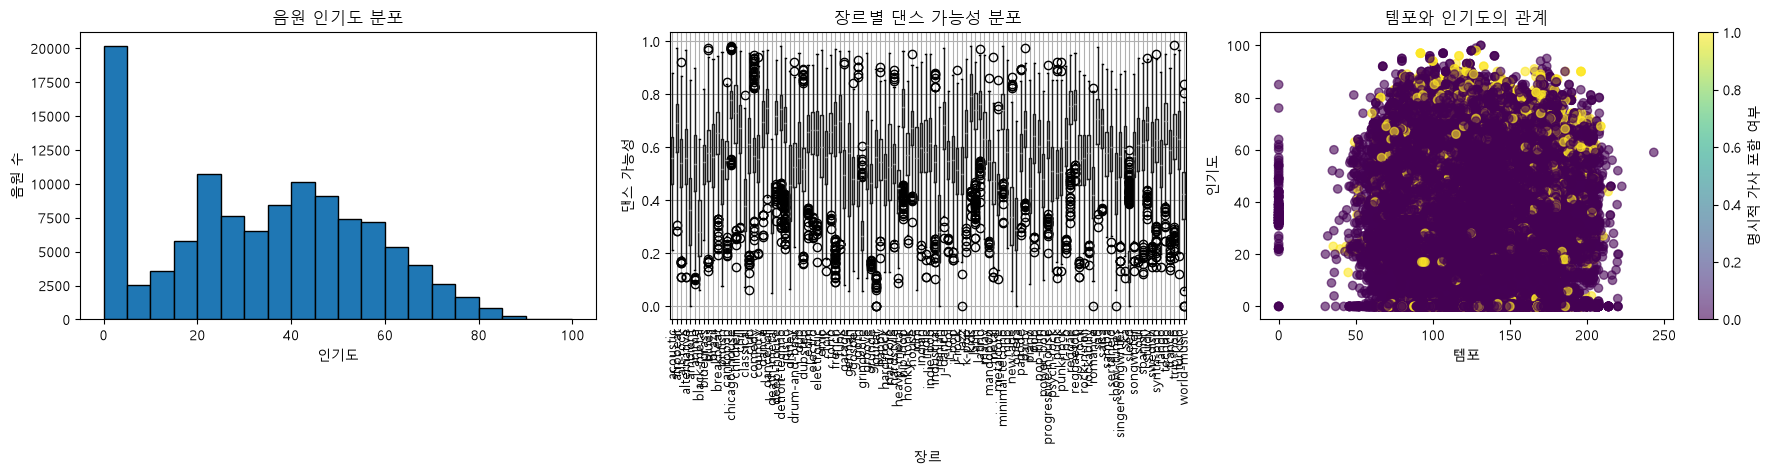

In [61]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
fig.suptitle("스포티파이 음원 데이터 시각화", fontsize=16)

axes[0].hist(
    df['popularity'],
    bins=20,
    edgecolor='black'
)
axes[0].set_title("음원 인기도 분포")
axes[0].set_xlabel("인기도")
axes[0].set_ylabel("음원 수")

df.boxplot(
    column="danceability",
    by="track_genre",
    ax=axes[1]
)

axes[1].set_title("장르별 댄스 가능성 분포")
axes[1].set_xlabel("장르")
axes[1].set_ylabel("댄스 가능성")
axes[1].tick_params(axis="x", rotation=90)

plt.suptitle("")

scatter = axes[2].scatter(
    df["tempo"],
    df["popularity"],
    c=df["explicit"].astype(int),
    alpha=0.6
)

axes[2].set_title("템포와 인기도의 관계")
axes[2].set_xlabel("템포")
axes[2].set_ylabel("인기도")

cbar = fig.colorbar(scatter, ax=axes[2])
cbar.set_label("명시적 가사 포함 여부")

plt.tight_layout()
plt.show()


In [59]:

# 3. popularity 히스토그램
axes[0].hist(
    df["popularity"],
    bins=20,
    edgecolor="black"
)

axes[0].set_title("음원 인기도 분포")
axes[0].set_xlabel("인기도")
axes[0].set_ylabel("음원 수")


# 4. track_genre별 danceability 박스 플롯
df.boxplot(
    column="danceability",
    by="track_genre",
    ax=axes[1]
)

axes[1].set_title("장르별 댄스 가능성 분포")
axes[1].set_xlabel("장르")
axes[1].set_ylabel("댄스 가능성")
axes[1].tick_params(axis="x", rotation=90)


# pandas boxplot이 자동으로 만드는 제목 제거
plt.suptitle("")


# 5. tempo와 popularity 산점도
scatter = axes[2].scatter(
    df["tempo"],
    df["popularity"],
    c=df["explicit"].astype(int),
    alpha=0.6
)

axes[2].set_title("템포와 인기도의 관계")
axes[2].set_xlabel("템포")
axes[2].set_ylabel("인기도")


# 컬러바 추가
cbar = fig.colorbar(scatter, ax=axes[2])
cbar.set_label("명시적 가사 포함 여부")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>